# Gradient Boosting Classifier for Shopping Preference Prediction

In this notebook we implement **Gradient Boosting**, an advanced ensemble learning technique that builds models sequentially to correct errors made by previous models.

Unlike Random Forest, which builds trees independently, Gradient Boosting builds trees **one after another**, gradually improving predictions.

This notebook covers:

1. Mathematical intuition of Gradient Boosting
2. Bias–variance trade-off
3. When to use Gradient Boosting
4. When not to use Gradient Boosting
5. Hyperparameter tuning
6. Implementation with Scikit-Learn
7. Model interpretation

We apply Gradient Boosting to predict customer shopping preference:

- Online
- Store
- Hybrid

using behavioral and demographic features.

In [32]:
# Setup
import sys
sys.path.append("..")

# Import Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

# project modules
from src.data_loader import load_raw_data
from src.preprocess import preprocess_dataset

sns.set(style="whitegrid")

## Load the Dataset

The dataset is loaded using the project's centralized data loader.

In [33]:
dataset_name = "online vs store shopping dataset.csv"

df = load_raw_data(dataset_name)

df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


## Data Preprocessing

The preprocessing pipeline performs:

• Feature engineering  
• Encoding categorical variables  
• Scaling numerical features  
• Train/test split

In [34]:
X_train, X_test, y_train, y_test, preprocessor = preprocess_dataset(
    df,
    target_column="shopping_preference"
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (9431, 34)
Test shape: (2358, 34)


## Encode Target Variable

In [35]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Mathematical Intuition of Gradient Boosting

Gradient Boosting is an **ensemble learning algorithm** that builds models sequentially.

Instead of training independent trees like Random Forest, Gradient Boosting trains trees **one at a time**, where each new tree focuses on correcting the mistakes of the previous trees.

The algorithm works as follows:

1. Train a simple decision tree.
2. Measure the prediction errors.
3. Train a new tree that focuses on the residual errors.
4. Add the new tree to the model.
5. Repeat the process for many iterations.

Each new tree **moves the model toward the optimal prediction** using gradient descent optimization.

The final model is a weighted combination of many small trees called **weak learners**.

# Bias vs Variance Trade-off

Gradient Boosting reduces both **bias and variance** through sequential learning.

Single Decision Tree
- Low bias
- High variance

Random Forest
- Reduces variance

Gradient Boosting
- Reduces bias
- Reduces variance

However, if too many trees are used or if trees are too deep, Gradient Boosting can **overfit the training data**.

Regularization parameters help control this behavior.

# When to Use Gradient Boosting

Gradient Boosting performs very well when:

✔ The dataset contains complex nonlinear relationships  
✔ Feature interactions are important  
✔ High predictive accuracy is required  
✔ Structured/tabular data is used  

Typical applications include:

- customer behavior modeling
- fraud detection
- credit scoring
- recommendation systems

# When NOT to Use Gradient Boosting

Gradient Boosting may not be ideal when:

❌ Dataset is extremely large and training time is critical  
❌ Real-time prediction speed is extremely important  
❌ Model interpretability must be very simple  

Because the model consists of many trees, it can become computationally expensive compared to simpler algorithms.

## Train Baseline Model

In [36]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train_enc)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [37]:
pred_enc = gb.predict(X_test)

pred = le.inverse_transform(pred_enc)

## Model Evaluation

In [38]:
print("Accuracy:", accuracy_score(y_test, pred))

print("F1 Score:", f1_score(y_test, pred, average="weighted"))

print("\nClassification Report:\n")

print(classification_report(y_test, pred, zero_division=0))

Accuracy: 0.9635284139100933
F1 Score: 0.9529853317634951

Classification Report:

              precision    recall  f1-score   support

      Hybrid       0.43      0.08      0.14        74
      Online       0.88      0.95      0.91       235
       Store       0.98      1.00      0.99      2049

    accuracy                           0.96      2358
   macro avg       0.76      0.68      0.68      2358
weighted avg       0.95      0.96      0.95      2358



## Confusion Matrix

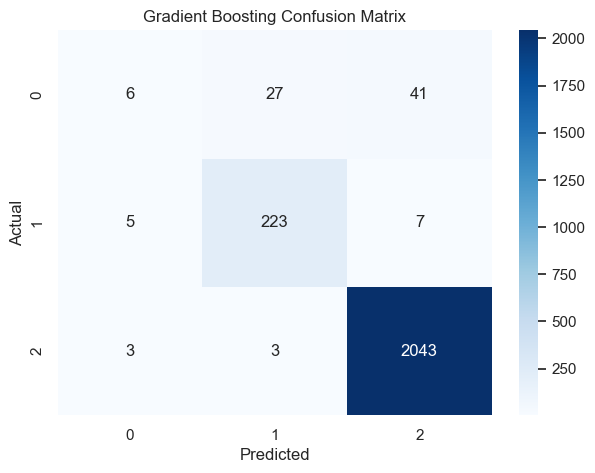

In [39]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Gradient Boosting Confusion Matrix")

plt.ylabel("Actual")

plt.xlabel("Predicted")

plt.show()

# Hyperparameter Tuning

Important Gradient Boosting parameters:

| Parameter | Meaning |
|------|------|
| n_estimators | Number of boosting stages |
| learning_rate | Step size of boosting |
| max_depth | Maximum depth of trees |
| min_samples_split | Minimum samples for split |
| min_samples_leaf | Minimum samples in leaf |

In [40]:
param_grid = {
    "n_estimators": [100,200,300],
    "learning_rate": [0.01,0.05,0.1],
    "max_depth": [3,5,7],
    "min_samples_split": [2,5],
    "min_samples_leaf": [1,2]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train, y_train_enc)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [41]:
best_gb = grid.best_estimator_

pred_enc = best_gb.predict(X_test)

pred = le.inverse_transform(pred_enc)

print(classification_report(y_test, pred, zero_division=0))

              precision    recall  f1-score   support

      Hybrid       0.49      0.26      0.34        74
      Online       0.92      0.94      0.93       235
       Store       0.98      0.99      0.99      2049

    accuracy                           0.97      2358
   macro avg       0.80      0.73      0.75      2358
weighted avg       0.96      0.97      0.96      2358



# Feature Importance

Gradient Boosting provides feature importance scores that indicate which variables most strongly influence predictions.

In [42]:
importances = best_gb.feature_importances_

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

importance_df.head(10)

,feature,importance
10,num__avg_store_spend,0.740738
18,num__need_touch_feel_score,0.070854
22,num__online_order_ratio,0.052372
25,num__digital_engagement_score,0.047050
6,num__tech_savvy_score,0.019948
23,num__online_spend_ratio,0.017360
5,num__online_payment_trust_score,0.009859
16,num__product_availability_online,0.006278
8,num__monthly_store_visits,0.005335
29,num__offline_shopping_preference_score,0.004179


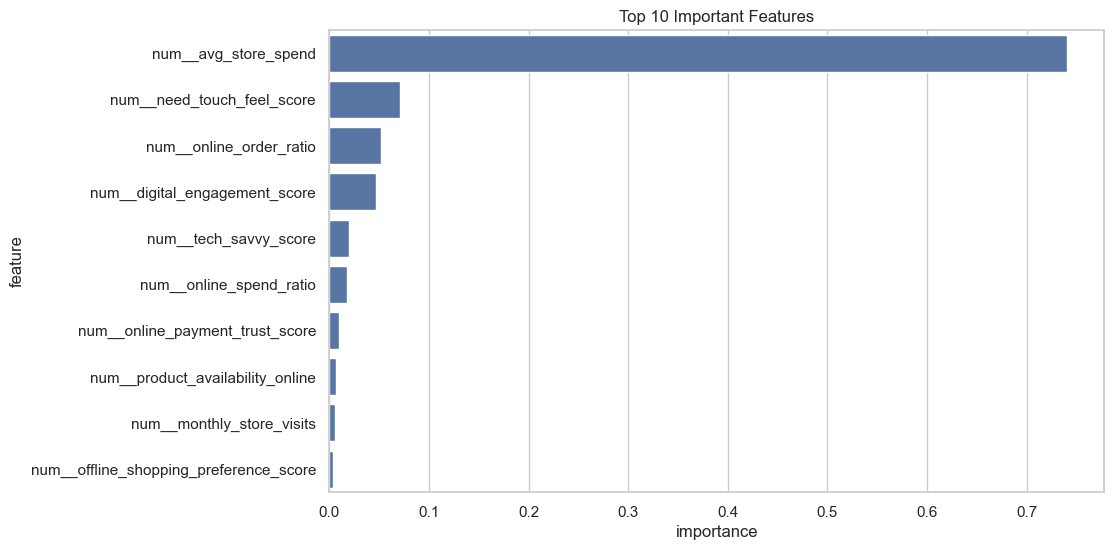

In [43]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x="importance",
    y="feature"
)

plt.title("Top 10 Important Features")

plt.show()

# Key Insights

Gradient Boosting often produces **higher predictive accuracy** than single models.

Key observations:

• Sequential learning allows the model to focus on difficult examples  
• Boosting reduces both bias and variance  
• Feature importance reveals the strongest drivers of customer shopping behavior

However, careful hyperparameter tuning is required to avoid overfitting.